# Credit and Fraud Risk Models: Robust Evaluation and Fairness Audit

This project takes two classifiers used for credit and fraud risk, logistic regression and gradient boosting, and tests how far their results can be trusted. A single train/test split can make a model look better or worse than it really is, and a model can perform well overall while treating some customer groups unfairly. The notebook checks both.

**Data sets**

| | Fraud | Default |
|---|---|---|
| Source | Credit Card Fraud Detection, ULB Machine Learning Group (Kaggle) | Default of Credit Card Clients, UCI Machine Learning Repository |
| Rows | 284,807 card transactions | 30,000 credit card accounts |
| Positive rate | 0.17% fraudulent | 22.1% defaulted |
| Features | Amount and 28 anonymised PCA components | Credit limit, demographics, 6 months of repayment history |

**What the notebook does**

1. Trains both models with class weighting and a stratified 75:25 split (baseline scores)
2. Repeats the evaluation with stratified 5-fold cross-validation
3. Checks whether tuning the decision threshold on the test set inflates results
4. Tests the fraud models on a time-ordered split
5. Plots learning curves to see whether more data would help
6. Audits the default models for bias with Microsoft Fairlearn, including a model trained without demographic attributes
7. Tests a fairness mitigation and measures what it costs



In [1]:
pip install pandas numpy scikit-learn matplotlib fairlearn xlrd

Note: you may need to restart the kernel to use updated packages.


## 1. Setup: imports, data and models

Both data sets are cleaned the same way throughout:
- **Fraud:** `Time` is dropped, because it records seconds since the start of a two-day collection window rather than anything about the transaction.
- **Default:** undocumented `EDUCATION` codes (0, 5, 6) and `MARRIAGE` code 0 are folded into the existing "other" categories.

Logistic regression is scaled inside a pipeline so the scaler only ever sees training data. Both models use `class_weight="balanced"` so they cannot ignore the minority class. A fixed seed (42) makes every result reproducible.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_score, cross_val_predict, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, recall_score,
                             precision_score, fbeta_score)
from fairlearn.metrics import (MetricFrame, count, selection_rate, true_positive_rate,
                               false_positive_rate, equalized_odds_difference)
from fairlearn.postprocessing import ThresholdOptimizer

import warnings
warnings.filterwarnings("ignore")
RS = 42
pd.set_option("display.width", 160)

In [3]:
def load_default():
    d = pd.read_excel("default of credit card clients.xls", header=1)
    d = d.drop(columns=[c for c in ["ID", "Unnamed: 0"] if c in d.columns])
    d = d.rename(columns={"default payment next month": "DEFAULT"})
    d["EDUCATION"] = d["EDUCATION"].replace({0: 4, 5: 4, 6: 4})   # undocumented codes -> other
    d["MARRIAGE"] = d["MARRIAGE"].replace({0: 3})
    return d.drop(columns=["DEFAULT"]), d["DEFAULT"]

def load_fraud(keep_time=False):
    f = pd.read_csv("creditcard.csv")
    t = f["Time"]
    f = f.drop(columns=["Time"])          # collection artefact, not a property of the transaction
    X, y = f.drop(columns=["Class"]), f["Class"]
    return (X, y, t) if keep_time else (X, y)

def lr():
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RS))

def gb():
    return HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, class_weight="balanced",
                                          early_stopping=True, validation_fraction=0.1, random_state=RS)

def split(X, y):
    return train_test_split(X, y, test_size=0.25, stratify=y, random_state=RS)

data = {"Default": load_default(), "Fraud": load_fraud()}
models = {"Logistic Regression": lr, "Gradient Boosting": gb}
for name, (X, y) in data.items():
    print(f"{name}: {X.shape[0]:,} rows, {X.shape[1]} features, positive rate {y.mean():.4%}")

Default: 30,000 rows, 23 features, positive rate 22.1200%
Fraud: 284,807 rows, 29 features, positive rate 0.1727%


## 2. Baseline: single stratified hold-out split

A stratified 75:25 split keeps each data set's positive rate the same in training and test data. These scores are the reference point that the later sections test for robustness. PR-AUC is the main metric because it focuses on the rare positive class.

In [4]:
rows = []
for dn, (X, y) in data.items():
    Xtr, Xte, ytr, yte = split(X, y)
    for mn, mk in models.items():
        p = mk().fit(Xtr, ytr).predict_proba(Xte)[:, 1]
        rows.append(dict(dataset=dn, model=mn, pr_auc=average_precision_score(yte, p),
                         roc_auc=roc_auc_score(yte, p), recall=recall_score(yte, p >= .5),
                         precision=precision_score(yte, p >= .5)))
pd.DataFrame(rows).round(4)

,dataset,model,pr_auc,roc_auc,recall,precision
0,Default,Logistic Regression,0.4998,0.7162,0.6305,0.3688
1,Default,Gradient Boosting,0.5526,0.7776,0.6251,0.4566
2,Fraud,Logistic Regression,0.7036,0.9727,0.8862,0.0607
3,Fraud,Gradient Boosting,0.7217,0.9710,0.8699,0.2884


## 3. Stratified 5-fold cross-validation

One split gives one estimate. Cross-validation shows how much the scores move between different samples of the data. Five folds, rather than ten, keeps about 98 frauds in every Fraud test fold.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
cv_rows = []
for dn, (X, y) in data.items():
    for mn, mk in models.items():
        r = cross_validate(mk(), X, y, cv=skf, n_jobs=-1,
                           scoring={"pr_auc": "average_precision", "roc_auc": "roc_auc",
                                    "recall": "recall", "precision": "precision"})
        row = dict(dataset=dn, model=mn)
        for k in ["pr_auc", "roc_auc", "recall", "precision"]:
            row[f"{k}_mean"] = r[f"test_{k}"].mean()
            row[f"{k}_sd"] = r[f"test_{k}"].std(ddof=1)
        cv_rows.append(row)
pd.DataFrame(cv_rows).round(3)

,dataset,model,pr_auc_mean,pr_auc_sd,roc_auc_mean,roc_auc_sd,recall_mean,recall_sd,precision_mean,precision_sd
0,Default,Logistic Regression,0.502,0.008,0.723,0.005,0.640,0.006,0.379,0.005
1,Default,Gradient Boosting,0.558,0.008,0.783,0.006,0.632,0.019,0.468,0.009
2,Fraud,Logistic Regression,0.742,0.024,0.979,0.009,0.911,0.026,0.063,0.003
3,Fraud,Gradient Boosting,0.749,0.027,0.963,0.013,0.860,0.020,0.380,0.073


Paired comparison on identical folds: how often does gradient boosting beat logistic regression, and by how much?

In [6]:
for dn, (X, y) in data.items():
    a = cross_val_score(lr(), X, y, cv=skf, scoring="average_precision", n_jobs=-1)
    b = cross_val_score(gb(), X, y, cv=skf, scoring="average_precision", n_jobs=-1)
    print(f"{dn}: GB - LR per fold = {np.round(b - a, 4)}, GB wins {(b > a).sum()}/5")

Default: GB - LR per fold = [0.0637 0.0581 0.0404 0.059  0.0617], GB wins 5/5
Fraud: GB - LR per fold = [ 0.0013  0.0418 -0.0141  0.0029  0.0043], GB wins 4/5


Fraud: GB - LR per fold = [ 0.0013  0.0418 -0.0141  0.0029  0.0043], GB wins 4/5


## 4. Decision threshold: test-set tuning versus training-only tuning

A common shortcut is to pick the threshold that maximises F2 (which weights recall twice as heavily as precision) directly on the test set. That lets test information leak into a modelling decision. Here the shortcut is compared with choosing the threshold on out-of-fold predictions from the training data only.

In [7]:
grid = np.arange(0.05, 0.96, 0.01)
def best_threshold(y, p):
    scores = [fbeta_score(y, (p >= t).astype(int), beta=2, zero_division=0) for t in grid]
    return grid[int(np.argmax(scores))], max(scores)

thr_rows = []
for dn, (X, y) in data.items():
    Xtr, Xte, ytr, yte = split(X, y)
    for mn, mk in models.items():
        pte = mk().fit(Xtr, ytr).predict_proba(Xte)[:, 1]
        t_test, f2_test = best_threshold(yte, pte)                       # chosen on the test set (optimistic)
        oof = cross_val_predict(mk(), Xtr, ytr, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]
        t_train, _ = best_threshold(ytr, oof)                              # training data only
        thr_rows.append(dict(dataset=dn, model=mn, threshold_test_tuned=t_test, F2_test_tuned=f2_test,
                             threshold_train_tuned=t_train,
                             F2_train_tuned=fbeta_score(yte, (pte >= t_train).astype(int), beta=2)))
pd.DataFrame(thr_rows).round(3)

,dataset,model,threshold_test_tuned,F2_test_tuned,threshold_train_tuned,F2_train_tuned
0,Default,Logistic Regression,0.12,0.588,0.32,0.585
1,Default,Gradient Boosting,0.32,0.639,0.31,0.638
2,Fraud,Logistic Regression,0.95,0.714,0.95,0.714
3,Fraud,Gradient Boosting,0.91,0.784,0.90,0.778


## 5. Temporal split on the Fraud data

Fraud patterns change over time, so a random split may be optimistic. Here the models train on the first 75% of transactions in time order and are tested on the last 25%.

In [8]:
X, y, t = load_fraud(keep_time=True)
order = t.sort_values(kind="stable").index
cut = int(0.75 * len(order))
train_idx, test_idx = order[:cut], order[cut:]
print(f"Fraud rate: train {y.loc[train_idx].mean():.4%}, test {y.loc[test_idx].mean():.4%}")
temp_rows = []
for mn, mk in models.items():
    p = mk().fit(X.loc[train_idx], y.loc[train_idx]).predict_proba(X.loc[test_idx])[:, 1]
    temp_rows.append(dict(model=mn, pr_auc=average_precision_score(y.loc[test_idx], p),
                          recall=recall_score(y.loc[test_idx], p >= .5),
                          precision=precision_score(y.loc[test_idx], p >= .5)))
pd.DataFrame(temp_rows).round(3)

Fraud rate: train 0.1863%, test 0.1320%


,model,pr_auc,recall,precision
0,Logistic Regression,0.761,0.883,0.045
1,Gradient Boosting,0.758,0.798,0.306


## 6. Learning curves

PR-AUC on 5% to 100% of each training fold, using the same five stratified folds. If training and validation scores meet early, the model has reached its limit and more data will not help (high bias). A persistent gap suggests the model would benefit from more data (high variance).

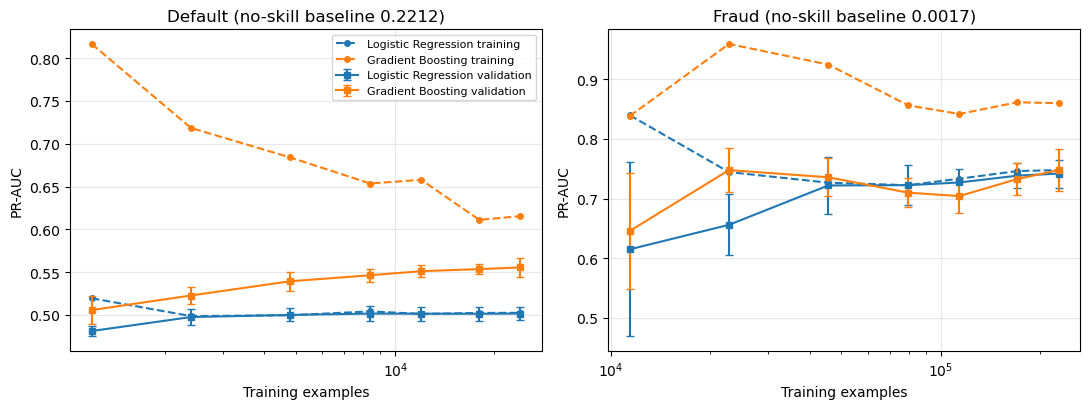

,dataset,model,n_train,train,val,val_sd
0,Default,Logistic Regression,1200,0.519,0.481,0.006
1,Default,Logistic Regression,2400,0.499,0.498,0.009
2,Default,Logistic Regression,4800,0.500,0.500,0.008
3,Default,Logistic Regression,8400,0.504,0.502,0.009
4,Default,Logistic Regression,12000,0.501,0.501,0.008
5,Default,Logistic Regression,18000,0.502,0.501,0.008
6,Default,Logistic Regression,24000,0.502,0.502,0.008
7,Default,Gradient Boosting,1200,0.817,0.506,0.017
8,Default,Gradient Boosting,2400,0.718,0.523,0.009
9,Default,Gradient Boosting,4800,0.684,0.539,0.011


In [9]:
sizes = [0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
lc_rows = []
for ax, (dn, (X, y)) in zip(axes, data.items()):
    for (mn, mk), colour in zip(models.items(), ["tab:blue", "tab:orange"]):
        n, tr, va = learning_curve(mk(), X, y, cv=skf, train_sizes=sizes, scoring="average_precision",
                                   n_jobs=-1, shuffle=True, random_state=RS)
        ax.plot(n, tr.mean(1), "--o", color=colour, label=f"{mn} training", ms=4)
        ax.errorbar(n, va.mean(1), yerr=va.std(1, ddof=1), fmt="-s", color=colour,
                    label=f"{mn} validation", ms=4, capsize=3)
        for i in range(len(n)):
            lc_rows.append(dict(dataset=dn, model=mn, n_train=n[i], train=tr.mean(1)[i],
                                val=va.mean(1)[i], val_sd=va.std(1, ddof=1)[i]))
    ax.set_xscale("log"); ax.set_xlabel("Training examples"); ax.set_ylabel("PR-AUC")
    ax.set_title(f"{dn} (no-skill baseline {y.mean():.4f})"); ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig("learning_curve.png", dpi=150); plt.show()
pd.DataFrame(lc_rows).round(3)

## 7. Fairness audit with Fairlearn (Default data set)

The Default data records sex, age, education and marital status, so its models can be audited. A positive prediction means a customer is flagged as a likely defaulter, so the key harm is the **false positive rate (FPR)**: the share of customers who would have repaid but are flagged anyway. All results use the hold-out test set and a 0.5 threshold.

A third model is gradient boosting retrained **without** the four demographic columns, to test whether leaving them out removes the gaps. The Fraud data cannot be audited this way because its features are anonymised.

In [10]:
X, y = data["Default"]
Xtr, Xte, ytr, yte = split(X, y)
age_bins, age_labels = [0, 29, 39, 49, 200], ["<30", "30-39", "40-49", "50+"]
sens = pd.DataFrame({
    "Sex": Xte["SEX"].map({1: "Male", 2: "Female"}),
    "Age": pd.cut(Xte["AGE"], age_bins, labels=age_labels).astype(str),
    "Education": Xte["EDUCATION"].map({1: "Graduate school", 2: "University", 3: "High school", 4: "Other"}),
    "Marriage": Xte["MARRIAGE"].map({1: "Married", 2: "Single", 3: "Other"}),
})
metrics = {"n": count, "default_rate": lambda yt, yp: yt.mean(), "selection_rate": selection_rate,
           "TPR": true_positive_rate, "FPR": false_positive_rate,
           "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0)}

demographics = ["SEX", "AGE", "EDUCATION", "MARRIAGE"]
variants = {
    "LR": (lr().fit(Xtr, ytr), Xte),
    "GB": (gb().fit(Xtr, ytr), Xte),
    "GB, no demographics": (gb().fit(Xtr.drop(columns=demographics), ytr), Xte.drop(columns=demographics)),
}
preds = {}
for vn, (m, Xe) in variants.items():
    p = m.predict_proba(Xe)[:, 1]
    preds[vn] = (p >= 0.5).astype(int)
    print(f"{vn}: PR-AUC {average_precision_score(yte, p):.3f}")

LR: PR-AUC 0.500
GB: PR-AUC 0.553
GB, no demographics: PR-AUC 0.552


In [11]:
for attr in ["Sex", "Age", "Education"]:
    table = pd.concat({vn: MetricFrame(metrics=metrics, y_true=yte, y_pred=yp,
                                       sensitive_features=sens[attr]).by_group[["n", "default_rate", "FPR", "TPR"]]
                       for vn, yp in preds.items()}, axis=1)
    print(f"\n=== {attr} ==="); display(table.round(3))


=== Sex ===


LR                                 GB                            GB, no demographics                           
             n default_rate    FPR    TPR       n default_rate    FPR    TPR                   n default_rate    FPR    TPR
Sex                                                                                                                        
Female  4517.0        0.212  0.253  0.598  4517.0        0.212  0.199  0.627              4517.0        0.212  0.207  0.626
Male    2983.0        0.235  0.391  0.675  2983.0        0.235  0.230  0.623              2983.0        0.235  0.225  0.623


=== Age ===


LR                                 GB                            GB, no demographics                           
            n default_rate    FPR    TPR       n default_rate    FPR    TPR                   n default_rate    FPR    TPR
Age                                                                                                                       
30-39  2769.0        0.201  0.267  0.607  2769.0        0.201  0.194  0.601              2769.0        0.201  0.191  0.592
40-49  1641.0        0.234  0.349  0.641  1641.0        0.234  0.212  0.615              1641.0        0.234  0.203  0.604
50+     710.0        0.252  0.460  0.698   710.0        0.252  0.249  0.642               710.0        0.252  0.232  0.615
<30    2380.0        0.226  0.281  0.625  2380.0        0.226  0.221  0.651              2380.0        0.226  0.244  0.675


=== Education ===


LR                                 GB                            GB, no demographics                           
                      n default_rate    FPR    TPR       n default_rate    FPR    TPR                   n default_rate    FPR    TPR
Education                                                                                                                           
Graduate school  2654.0        0.188  0.264  0.582  2654.0        0.188  0.177  0.590              2654.0        0.188  0.184  0.606
High school      1256.0        0.253  0.330  0.550  1256.0        0.253  0.267  0.619              1256.0        0.253  0.264  0.604
Other              96.0        0.062  0.067  0.167    96.0        0.062  0.044  0.167                96.0        0.062  0.111  0.333
University       3494.0        0.239  0.340  0.693  3494.0        0.239  0.225  0.651              3494.0        0.239  0.224  0.646

In [12]:
summary = []
for vn, yp in preds.items():
    for attr in ["Sex", "Age"]:
        summary.append(dict(model=vn, attribute=attr,
                            equalised_odds_difference=equalized_odds_difference(yte, yp, sensitive_features=sens[attr])))
pd.DataFrame(summary).pivot(index="model", columns="attribute", values="equalised_odds_difference").round(3)

attribute,Age,Sex
model,,
GB,0.055,0.031
"GB, no demographics",0.083,0.019
LR,0.193,0.138


## 8. Mitigation with ThresholdOptimizer

Fairlearn's `ThresholdOptimizer` sets a separate threshold for each age group so that true and false positive rates are closer across groups (equalised odds). The table shows the fairness gain and what it costs in share of customers flagged, recall and precision.

In [13]:
age_train = pd.cut(Xtr["AGE"], age_bins, labels=age_labels).astype(str)
base = variants["GB"][0]
to = ThresholdOptimizer(estimator=base, constraints="equalized_odds", objective="balanced_accuracy_score",
                        prefit=True, predict_method="predict_proba")
to.fit(Xtr, ytr, sensitive_features=age_train)
y_fair = to.predict(Xte, sensitive_features=sens["Age"], random_state=RS)

rows = []
for label, yp in [("before", preds["GB"]), ("after", y_fair)]:
    rows.append(dict(stage=label, eo_difference=equalized_odds_difference(yte, yp, sensitive_features=sens["Age"]),
                     share_flagged=yp.mean(), recall=recall_score(yte, yp), precision=precision_score(yte, yp)))
pd.DataFrame(rows).round(3)

,stage,eo_difference,share_flagged,recall,precision
0,before,0.055,0.303,0.625,0.457
1,after,0.033,0.361,0.673,0.412


## Summary of findings

- **Cross-validation:** on the Default data, gradient boosting beats logistic regression in all five folds (PR-AUC about 0.558 against 0.502). On the Fraud data the two models are effectively tied (about 0.749 against 0.742, a gap well inside the fold-to-fold variation of about 0.025).
- **Threshold tuning:** choosing the threshold on the test set inflates F2 only slightly (up to 0.006), but the best threshold for logistic regression on Default is unstable (0.12 against 0.32).
- **Time:** on the time-ordered Fraud split, PR-AUC holds up but the fraud rate drops and the model ranking reverses, a warning that random splits can hide change over time.
- **Learning curves:** logistic regression plateaus early on both data sets (high bias). On the Fraud data, performance depends on the number of frauds seen, not the number of transactions.
- **Fairness:** logistic regression flags non-defaulting men and customers aged 50+ far more often than others (FPR 0.391 against 0.253 by sex; 0.460 for 50+). Gradient boosting's gaps are much smaller. Removing demographic columns does not remove the education gap, because repayment behaviour acts as a proxy.
- **Mitigation:** ThresholdOptimizer narrows the age gap (equalised odds difference 0.055 to 0.033) at the cost of flagging more customers (30.3% to 36.1%) and lower precision.